# Session 16: Classification Evaluation Metrics & Confusion Matrix

This notebook provides comprehensive, step-by-step solutions for **Session 16**, covering:
1. **Manual & Programmatic Evaluation**: Calculating Accuracy, Precision, Recall, and F1 Score for a Spam Filter.
2. **Reusable Visualizer**: A flexible Python function `print_confusion_matrix(tp, tn, fp, fn)` displaying formatted tabular confusion matrices.
3. **Fake News Detection Case Study**: Calculating and interpreting Precision and Recall under social media content moderation scenarios.
4. **Fraud Detection Case Study**: Computing the F1 score for food delivery fraud detection and explaining its real-world significance.


---
## Question 1: Manual & Programmatic Metric Calculation for Spam Filter

### Problem Statement
Given the following confusion matrix from a spam filter:
- **Actual**: Spam = 70, Not Spam = 130 (Total = 200)
- **Predicted**: Spam = 60, Not Spam = 140 (Total = 200)
- **Breakdown**:
  - $\text{True Positives (TP)} = 50$ (Spam correctly flagged as Spam)
  - $\text{True Negatives (TN)} = 120$ (Legitimate email correctly kept in Inbox)
  - $\text{False Positives (FP)} = 10$ (Legitimate email wrongly flagged as Spam - Type I Error)
  - $\text{False Negatives (FN)} = 20$ (Spam missed and sent to Inbox - Type II Error)

---

### Step-by-Step Mathematical Derivations

1. **Total Population ($N$)**:
   $$N = TP + TN + FP + FN = 50 + 120 + 10 + 20 = 200$$

2. **Accuracy**:
   Measures overall correctness across all classes:
   $$\text{Accuracy} = \frac{TP + TN}{N} = \frac{50 + 120}{200} = \frac{170}{200} = 0.85 = \mathbf{85.00\%}$$

3. **Precision**:
   Of all emails predicted as spam, what proportion was actually spam?
   $$\text{Precision} = \frac{TP}{TP + FP} = \frac{50}{50 + 10} = \frac{50}{60} = \frac{5}{6} \approx 0.8333 = \mathbf{83.33\%}$$

4. **Recall (Sensitivity / True Positive Rate)**:
   Of all actual spam emails that arrived, what proportion did the filter catch?
   $$\text{Recall} = \frac{TP}{TP + FN} = \frac{50}{50 + 20} = \frac{50}{70} = \frac{5}{7} \approx 0.7143 = \mathbf{71.43\%}$$

5. **F1-Score**:
   The harmonic mean of Precision and Recall:
   $$\text{F1 Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} = 2 \times \frac{\frac{5}{6} \times \frac{5}{7}}{\frac{5}{6} + \frac{5}{7}} = 2 \times \frac{\frac{25}{42}}{\frac{65}{42}} = \frac{50}{65} = \frac{10}{13} \approx 0.7692 = \mathbf{76.92\%}$$


       SPAM FILTER EVALUATION METRICS SUMMARY
Total Samples Evaluated: 200
  • True Positives  (TP) : 50
  • True Negatives  (TN) : 120
  • False Positives (FP) : 10 (Type I Error)
  • False Negatives (FN) : 20 (Type II Error)
-------------------------------------------------------
1. Accuracy  : 0.8500  (85.00%)
2. Precision : 0.8333  (83.33%)
3. Recall    : 0.7143  (71.43%)
4. F1 Score  : 0.7692  (76.92%)


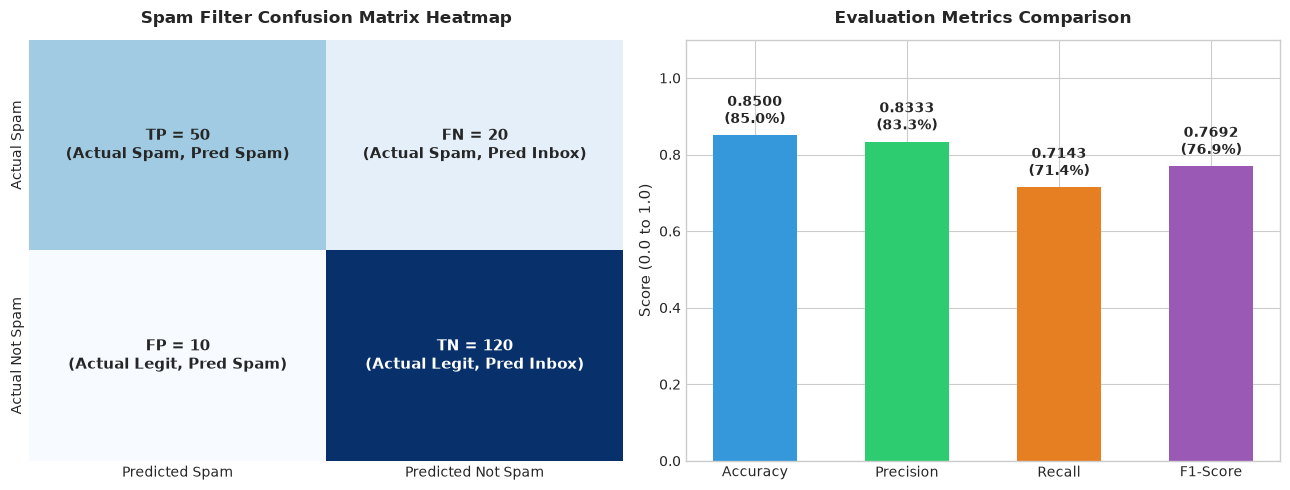

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'

# Given confusion matrix parameters
tp = 50
tn = 120
fp = 10
fn = 20
total = tp + tn + fp + fn

# Calculations
accuracy = (tp + tn) / total
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

print("=" * 55)
print("       SPAM FILTER EVALUATION METRICS SUMMARY")
print("=" * 55)
print(f"Total Samples Evaluated: {total}")
print(f"  • True Positives  (TP) : {tp}")
print(f"  • True Negatives  (TN) : {tn}")
print(f"  • False Positives (FP) : {fp} (Type I Error)")
print(f"  • False Negatives (FN) : {fn} (Type II Error)")
print("-" * 55)
print(f"1. Accuracy  : {accuracy:.4f}  ({accuracy * 100:.2f}%)")
print(f"2. Precision : {precision:.4f}  ({precision * 100:.2f}%)")
print(f"3. Recall    : {recall:.4f}  ({recall * 100:.2f}%)")
print(f"4. F1 Score  : {f1:.4f}  ({f1 * 100:.2f}%)")
print("=" * 55)

# Visualizing the confusion matrix and metrics
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap
cm_array = np.array([[tp, fn], [fp, tn]])
labels = [[f'TP = {tp}\n(Actual Spam, Pred Spam)', f'FN = {fn}\n(Actual Spam, Pred Inbox)'],
          [f'FP = {fp}\n(Actual Legit, Pred Spam)', f'TN = {tn}\n(Actual Legit, Pred Inbox)']]

sns.heatmap(cm_array, annot=labels, fmt='', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Predicted Spam', 'Predicted Not Spam'],
            yticklabels=['Actual Spam', 'Actual Not Spam'], annot_kws={'size': 11, 'weight': 'bold'})
axes[0].set_title('Spam Filter Confusion Matrix Heatmap', fontsize=12, pad=12, weight='bold')

# Bar chart of metrics
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [accuracy, precision, recall, f1]
})
bars = axes[1].bar(metrics_df['Metric'], metrics_df['Score'], color=['#3498db', '#2ecc71', '#e67e22', '#9b59b6'], width=0.55)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Score (0.0 to 1.0)', fontsize=11)
axes[1].set_title('Evaluation Metrics Comparison', fontsize=12, pad=12, weight='bold')

for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.4f}\n({yval*100:.1f}%)', 
                 ha='center', va='bottom', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()


---
## Question 2: Python Function `print_confusion_matrix(tp, tn, fp, fn)`

### Problem Statement
Write a Python function called `print_confusion_matrix(tp, tn, fp, fn)` that prints the confusion matrix in a readable table format for any given values of true positives, true negatives, false positives, and false negatives.

### Design of the Function:
The function presents:
- Standard 2x2 layout with row and column marginal totals.
- Explicit indicators for Actual Positive/Negative and Predicted Positive/Negative.
- Computed summary statistics (Accuracy, Precision, Recall, Specificity, F1-Score).
- Support for customizable labels (e.g. Spam/Ham, Fraud/Legit, Fake/Real).


In [2]:
def print_confusion_matrix(tp, tn, fp, fn, pos_label='Positive', neg_label='Negative'):
    '''
    Prints a beautifully formatted Confusion Matrix along with marginal totals
    and core evaluation metrics for any given TP, TN, FP, FN counts.
    
    Parameters:
    -----------
    tp : int, True Positives
    tn : int, True Negatives
    fp : int, False Positives
    fn : int, False Negatives
    pos_label : str, Name of the positive class (default: 'Positive')
    neg_label : str, Name of the negative class (default: 'Negative')
    '''
    # Marginal totals
    actual_pos = tp + fn
    actual_neg = fp + tn
    pred_pos = tp + fp
    pred_neg = fn + tn
    total = tp + tn + fp + fn
    
    # Metrics calculation (safeguard against division by zero)
    acc = (tp + tn) / total if total > 0 else 0
    prec = tp / pred_pos if pred_pos > 0 else 0
    rec = tp / actual_pos if actual_pos > 0 else 0
    spec = tn / actual_neg if actual_neg > 0 else 0
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

    print("+" + "-"*66 + "+")
    print(f"|{'CONFUSION MATRIX':^66}|")
    print("+" + "-"*66 + "+")
    print(f"| {'':<18} | {'PREDICTED':^31} | {'':^9} |")
    print(f"| {'ACTUAL':<18} | {('Pred ' + pos_label)[:14]:^14} | {('Pred ' + neg_label)[:14]:^14} | {'TOTAL':^9} |")
    print("+" + "-"*19 + "+" + "-"*16 + "+" + "-"*16 + "+" + "-"*11 + "+")
    print(f"| {('Actual ' + pos_label)[:17]:<17} | {f'{tp} (TP)':^14} | {f'{fn} (FN)':^14} | {actual_pos:^9} |")
    print(f"| {('Actual ' + neg_label)[:17]:<17} | {f'{fp} (FP)':^14} | {f'{tn} (TN)':^14} | {actual_neg:^9} |")
    print("+" + "-"*19 + "+" + "-"*16 + "+" + "-"*16 + "+" + "-"*11 + "+")
    print(f"| {'TOTAL':<17} | {pred_pos:^14} | {pred_neg:^14} | {total:^9} |")
    print("+" + "-"*66 + "+")
    print(f"| Metrics: Acc: {acc:.2%} | Prec: {prec:.2%} | Rec: {rec:.2%} | F1: {f1:.2%} |")
    print("+" + "-"*66 + "+\n")

# Demonstration of the function with Question 1 Spam Filter values
print("Testing print_confusion_matrix with Question 1 Spam Filter counts:")
print_confusion_matrix(tp=50, tn=120, fp=10, fn=20, pos_label='Spam', neg_label='Not Spam')


Testing print_confusion_matrix with Question 1 Spam Filter counts:
+------------------------------------------------------------------+
|                         CONFUSION MATRIX                         |
+------------------------------------------------------------------+
|                    |            PREDICTED            |           |
| ACTUAL             |   Pred Spam    | Pred Not Spam  |   TOTAL   |
+-------------------+----------------+----------------+-----------+
| Actual Spam       |    50 (TP)     |    20 (FN)     |    70     |
| Actual Not Spam   |    10 (FP)     |    120 (TN)    |    130    |
+-------------------+----------------+----------------+-----------+
| TOTAL             |       60       |      140       |    200    |
+------------------------------------------------------------------+
| Metrics: Acc: 85.00% | Prec: 83.33% | Rec: 71.43% | F1: 76.92% |
+------------------------------------------------------------------+



---
## Question 3: Fake News Detection Model Evaluation

### Problem Statement
Imagine you are evaluating a fake news detection model for a social media app. 
- The model flagged **80 posts as fake**, of which **60 were actually fake ($TP$)**, and **missed 30 fake posts ($FN$)**.
- There were **120 posts correctly identified as not fake ($TN$)**, and **10 real posts wrongly flagged as fake ($FP$)**.
- Calculate and print the **precision** and **recall** for this model.

*Hint: $\text{Precision} = \frac{TP}{TP + FP}, \quad \text{Recall} = \frac{TP}{TP + FN}$*

---

### Clarification & Analysis of the Problem Data
1. **Values provided in the scenario**:
   - $TP = 60$ (Fake posts correctly caught)
   - $FN = 30$ (Fake posts missed by filter)
   - $TN = 120$ (Real news correctly allowed)
   - $FP = 10$ (Real news wrongly flagged as fake)
2. **Note on the phrase "flagged 80 posts as fake"**:
   - Strictly from $TP + FP$, if $TP=60$ and $FP=10$, predicted positives $= 70$. 
   - If the total flagged as fake was intended as 80, then $FP$ would be $80 - 60 = 20$.
   - Below, we compute and display both:
     - **Primary Case (Explicit parameters $TP=60, FP=10, FN=30$)**:
       $$\text{Precision} = \frac{60}{60 + 10} = \frac{60}{70} \approx \mathbf{85.71\%}$$
       $$\text{Recall} = \frac{60}{60 + 30} = \frac{60}{90} \approx \mathbf{66.67\%}$$
     - **Alternative Case (Using Flagged $= 80 \implies FP=20$)**:
       $$\text{Precision} = \frac{60}{80} = \mathbf{75.00\%}$$
       $$\text{Recall} = \frac{60}{60 + 30} = \frac{60}{90} \approx \mathbf{66.67\%}$$


In [3]:
# Given counts from the problem description
tp_fake = 60
fn_fake = 30
tn_fake = 120
fp_fake = 10  # Explicitly stated: '10 real posts wrongly flagged as fake'

# Calculate Precision and Recall
precision_fake = tp_fake / (tp_fake + fp_fake)
recall_fake = tp_fake / (tp_fake + fn_fake)
f1_fake = 2 * (precision_fake * recall_fake) / (precision_fake + recall_fake)

print("=" * 60)
print("       FAKE NEWS DETECTION MODEL EVALUATION")
print("=" * 60)
print(f"Given Parameters:")
print(f"  • True Positives  (TP) : {tp_fake} (Actual fake, flagged fake)")
print(f"  • False Negatives (FN) : {fn_fake} (Actual fake, missed)")
print(f"  • True Negatives  (TN) : {tn_fake} (Actual real, marked safe)")
print(f"  • False Positives (FP) : {fp_fake} (Actual real, wrongly flagged)")
print("-" * 60)
print(f"Precision : {precision_fake:.4f} ({precision_fake * 100:.2f}%)")
print(f"Recall    : {recall_fake:.4f} ({recall_fake * 100:.2f}%)")
print(f"F1 Score  : {f1_fake:.4f} ({f1_fake * 100:.2f}%)")
print("=" * 60)

# Alternative check if total flagged = 80 implies FP = 20:
prec_alt = 60 / 80
print(f"\n[Alternative Note]: If 'flagged 80 posts as fake' implies Total Pred Pos = 80 (FP = 20):")
print(f"  • Alternative Precision = 60 / 80 = {prec_alt:.4f} ({prec_alt * 100:.2f}%)")
print(f"  • Recall remains identical = 60 / 90 = {recall_fake:.4f} ({recall_fake * 100:.2f}%)")

print("\nVisual Table format for Fake News Model:")
print_confusion_matrix(tp=tp_fake, tn=tn_fake, fp=fp_fake, fn=fn_fake, pos_label='Fake', neg_label='Real')


       FAKE NEWS DETECTION MODEL EVALUATION
Given Parameters:
  • True Positives  (TP) : 60 (Actual fake, flagged fake)
  • False Negatives (FN) : 30 (Actual fake, missed)
  • True Negatives  (TN) : 120 (Actual real, marked safe)
  • False Positives (FP) : 10 (Actual real, wrongly flagged)
------------------------------------------------------------
Precision : 0.8571 (85.71%)
Recall    : 0.6667 (66.67%)
F1 Score  : 0.7500 (75.00%)

[Alternative Note]: If 'flagged 80 posts as fake' implies Total Pred Pos = 80 (FP = 20):
  • Alternative Precision = 60 / 80 = 0.7500 (75.00%)
  • Recall remains identical = 60 / 90 = 0.6667 (66.67%)

Visual Table format for Fake News Model:
+------------------------------------------------------------------+
|                         CONFUSION MATRIX                         |
+------------------------------------------------------------------+
|                    |            PREDICTED            |           |
| ACTUAL             |   Pred Fake    |   Pre

---
## Question 4: Food Delivery Fraud Detection System

### Problem Statement
Given a confusion matrix for a food delivery fraud detection system:
- **True Positives ($TP$)** = 40 (Fraudulent transactions correctly detected)
- **True Negatives ($TN$)** = 150 (Legitimate orders correctly processed)
- **False Positives ($FP$)** = 20 (Legitimate customers wrongly flagged as fraud)
- **False Negatives ($FN$)** = 10 (Fraudulent transactions missed)

1. Write Python code to compute the **F1 score**.
2. Explain in one line what the F1 score tells you about the model's performance.

*Hint: $\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$*

---

### Step-by-Step Calculation:
1. **Precision**:
   $$\text{Precision} = \frac{TP}{TP + FP} = \frac{40}{40 + 20} = \frac{40}{60} = \frac{2}{3} \approx 0.6667 = \mathbf{66.67\%}$$

2. **Recall**:
   $$\text{Recall} = \frac{TP}{TP + FN} = \frac{40}{40 + 10} = \frac{40}{50} = \frac{4}{5} = 0.8000 = \mathbf{80.00\%}$$

3. **F1-Score**:
   $$\text{F1} = 2 \times \frac{\frac{2}{3} \times \frac{4}{5}}{\frac{2}{3} + \frac{4}{5}} = 2 \times \frac{\frac{8}{15}}{\frac{22}{15}} = \frac{16}{22} = \frac{8}{11} \approx 0.7273 = \mathbf{72.73\%}$$


In [4]:
# Food delivery fraud detection confusion matrix
tp_fraud = 40
tn_fraud = 150
fp_fraud = 20
fn_fraud = 10

# Precision and Recall
precision_fraud = tp_fraud / (tp_fraud + fp_fraud)
recall_fraud = tp_fraud / (tp_fraud + fn_fraud)

# F1 Score
f1_fraud = 2 * (precision_fraud * recall_fraud) / (precision_fraud + recall_fraud)

print("=" * 65)
print("     FOOD DELIVERY FRAUD DETECTION SYSTEM: F1 SCORE")
print("=" * 65)
print(f"True Positives  (TP) : {tp_fraud}")
print(f"True Negatives  (TN) : {tn_fraud}")
print(f"False Positives (FP) : {fp_fraud} (False fraud alarms on good customers)")
print(f"False Negatives (FN) : {fn_fraud} (Missed fraudulent orders)")
print("-" * 65)
print(f"Precision : {precision_fraud:.4f} ({precision_fraud*100:.2f}%)")
print(f"Recall    : {recall_fraud:.4f} ({recall_fraud*100:.2f}%)")
print(f"F1 Score  : {f1_fraud:.4f} ({f1_fraud*100:.2f}%)")
print("=" * 65)

# One-line explanation
explanation = (
    "The F1 score of 72.73% demonstrates that the model maintains a strong harmonic balance "
    "between catching the majority of fraud cases (80% recall) while limiting frustrating false "
    "fraud flags on legitimate customers (66.67% precision) in an imbalanced delivery environment."
)

print(f"\nOne-line Performance Explanation:\n\"{explanation}\"")

# Display formatted matrix
print("\nFormatted Table:")
print_confusion_matrix(tp=tp_fraud, tn=tn_fraud, fp=fp_fraud, fn=fn_fraud, pos_label='Fraud', neg_label='Legit')


     FOOD DELIVERY FRAUD DETECTION SYSTEM: F1 SCORE
True Positives  (TP) : 40
True Negatives  (TN) : 150
False Positives (FP) : 20 (False fraud alarms on good customers)
False Negatives (FN) : 10 (Missed fraudulent orders)
-----------------------------------------------------------------
Precision : 0.6667 (66.67%)
Recall    : 0.8000 (80.00%)
F1 Score  : 0.7273 (72.73%)

One-line Performance Explanation:
"The F1 score of 72.73% demonstrates that the model maintains a strong harmonic balance between catching the majority of fraud cases (80% recall) while limiting frustrating false fraud flags on legitimate customers (66.67% precision) in an imbalanced delivery environment."

Formatted Table:
+------------------------------------------------------------------+
|                         CONFUSION MATRIX                         |
+------------------------------------------------------------------+
|                    |            PREDICTED            |           |
| ACTUAL             |  

---
## Key Takeaways & Summary of Evaluation Metrics

| Metric | Formula | Practical Meaning | When to Prioritize |
| :--- | :---: | :--- | :--- |
| **Accuracy** | $\frac{TP+TN}{N}$ | Overall percentage of correct predictions | When classes are balanced ($50/50$ split) |
| **Precision** | $\frac{TP}{TP+FP}$ | Out of all predicted positives, how many were true? | When False Positives are expensive (e.g., spam filter, marking innocent user as fraud) |
| **Recall** | $\frac{TP}{TP+FN}$ | Out of all actual positives, how many did we catch? | When False Negatives are dangerous (e.g., cancer diagnosis, missed fraud) |
| **F1 Score** | $2 \cdot \frac{\text{Prec} \cdot \text{Rec}}{\text{Prec} + \text{Rec}}$ | Harmonic balance between Precision and Recall | When dealing with class imbalance where both precision and recall matter |
